# SDG Indicator Text Classification



In [ ]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn beautifulsoup4 nltk

import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix,
)

%matplotlib inline

try:
    from google.colab import files  # noqa: F401
    IN_COLAB = True
    print("Running in Google Colab — place Devex_train.csv and Devex_test_questions.csv in /content/")
except ImportError:
    IN_COLAB = False

print(f"pandas {pd.__version__} | numpy {np.__version__} | colab={IN_COLAB}")



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
pandas 3.0.3 | numpy 2.4.6 | colab=False


In [2]:
# STEP 2: Load datasets
from IPython.display import display

TRAIN_PATH = "Devex_train.csv"
TEST_PATH = "Devex_test_questions.csv"

train_df = pd.read_csv(TRAIN_PATH, encoding="latin-1")
test_df = pd.read_csv(TEST_PATH, encoding="latin-1")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# snip display of the train and test datasets
print("\nTrain data (first 2 rows):")
display(train_df.head(2))

print("\nTest data (first 2 rows):")
display(test_df.head(2))


Train shape: (2995, 15)
Test shape: (998, 3)

Train data (first 2 rows):


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Test data (first 2 rows):


,Unique ID,Type,Text
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...
1,52348,Organization,Action for Global Health: <p>Action for Global...


## Parse labels + exploratory data analysis (EDA)


In [3]:
LABEL_COLS = [f"Label {i}" for i in range(1, 13)]


def extract_labels(row):
    """Return active SDG indicator strings for one row (ignore NA/NaN/empty)."""
    labels = []
    for col in LABEL_COLS:
        value = row[col]
        if pd.isna(value):
            continue
        value = str(value).strip()
        if value and value.upper() != "NA":
            labels.append(value)
    return labels


train_df["labels"] = train_df.apply(extract_labels, axis=1)
train_df["n_labels"] = train_df["labels"].apply(len)

# Build fixed label vocabulary from training set only
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(train_df["labels"])
label_names = mlb.classes_

print(f"Number of unique SDG 3 indicators: {len(label_names)}")
print(f"Label matrix shape (samples × labels): {Y.shape}")
print(f"Labels per document — min: {train_df['n_labels'].min()}, "
      f"max: {train_df['n_labels'].max()}, "
      f"mean: {train_df['n_labels'].mean():.2f}")

# Shared split settings for preprocessing ablation, baseline, and experiments 1–10
RANDOM_STATE = 42
TEST_SIZE = 0.2
y = Y

display(train_df[["Unique ID", "Type", "n_labels", "labels"]].head(3))

Number of unique SDG 3 indicators: 27
Label matrix shape (samples × labels): (2995, 27)
Labels per document — min: 1, max: 10, mean: 1.98


,Unique ID,Type,n_labels,labels
0,12555,Grant,2,[3.b.2 - Total net official development assist...
1,14108,Grant,1,[3.b.2 - Total net official development assist...
2,23168,Organization,4,[3.d.1 - International Health Regulations (IHR...


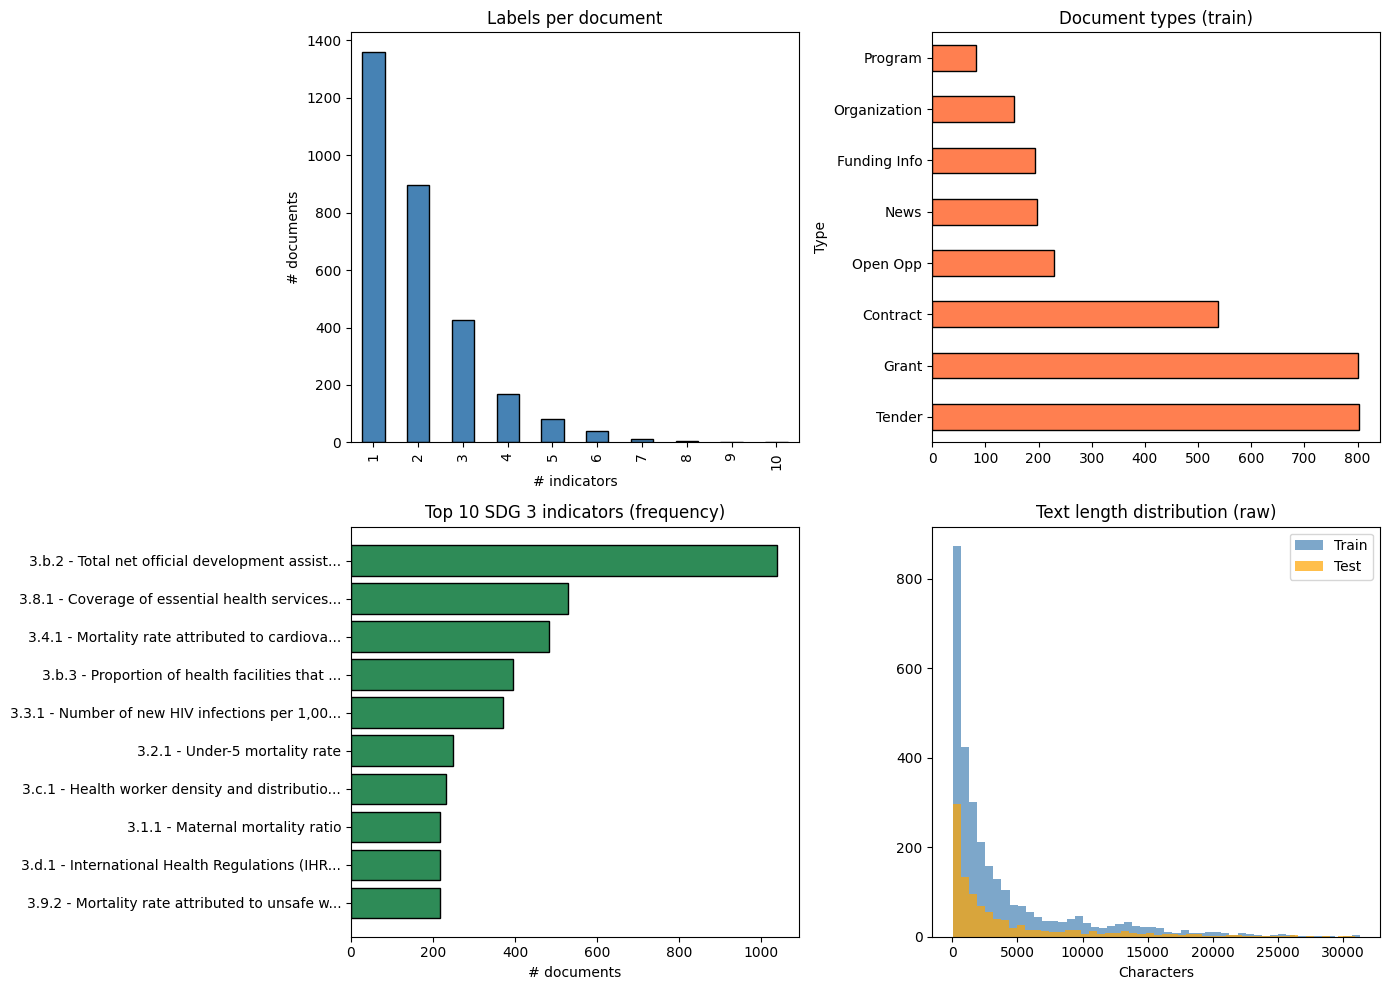


Label prevalence (documents containing each indicator):


,count
3.b.2 - Total net official development assistance to medical research and basic health sector,1040
"3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)",529
"3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease",483
3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,394
"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations",371
3.2.1 - Under-5 mortality rate,249
3.c.1 - Health worker density and distribution,232
3.1.1 - Maternal mortality ratio,218
"3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)",217
3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,217


In [4]:
# EDA visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Labels per document
train_df["n_labels"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="black"
)
axes[0, 0].set_title("Labels per document")
axes[0, 0].set_xlabel("# indicators")
axes[0, 0].set_ylabel("# documents")

# 2) Document type distribution
train_df["Type"].value_counts().plot(
    kind="barh", ax=axes[0, 1], color="coral", edgecolor="black"
)
axes[0, 1].set_title("Document types (train)")

# 3) Top 10 most frequent indicators
label_counts = Y.sum(axis=0)
top_idx = np.argsort(label_counts)[::-1][:10]
top_labels = [label_names[i][:45] + "..." if len(label_names[i]) > 45 else label_names[i]
              for i in top_idx]
axes[1, 0].barh(top_labels[::-1], label_counts[top_idx][::-1], color="seagreen", edgecolor="black")
axes[1, 0].set_title("Top 10 SDG 3 indicators (frequency)")
axes[1, 0].set_xlabel("# documents")

# 4) Text length (characters) before cleaning
train_df["text_len"] = train_df["Text"].astype(str).str.len()
test_df["text_len"] = test_df["Text"].astype(str).str.len()
axes[1, 1].hist(train_df["text_len"], bins=50, alpha=0.7, label="Train", color="steelblue")
axes[1, 1].hist(test_df["text_len"], bins=50, alpha=0.7, label="Test", color="orange")
axes[1, 1].set_title("Text length distribution (raw)")
axes[1, 1].set_xlabel("Characters")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nLabel prevalence (documents containing each indicator):")
prevalence = pd.Series(label_counts, index=label_names).sort_values(ascending=False)
display(prevalence.head(10).to_frame("count"))

# Class imbalance analysis


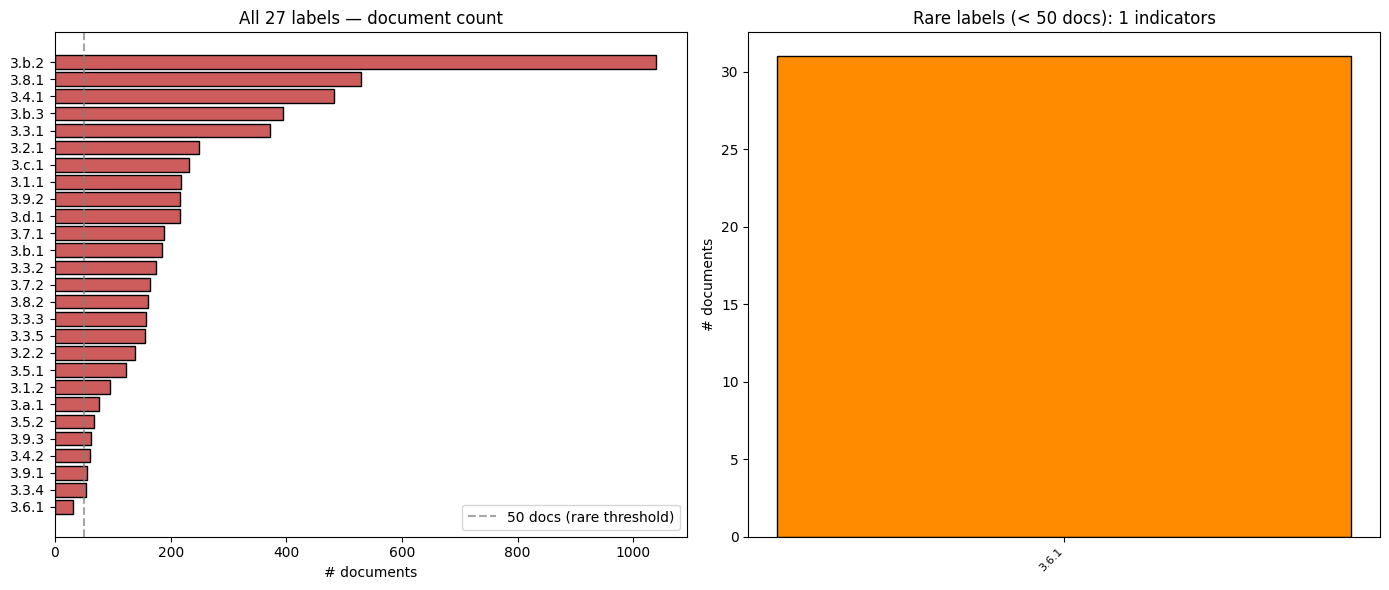

Most frequent: 3.b.2 - Total net official development assistance ... (1040 docs)
Least frequent: 3.6.1 - Death rate due to road traffic injuries... (31 docs)
Imbalance ratio (max/min): 33.5x


,indicator,count,pct_documents,imbalance_ratio
23,3.b.2 - Total net official development assista...,1040,34.72,1.0
16,3.8.1 - Coverage of essential health services ...,529,17.66,2.0
9,3.4.1 - Mortality rate attributed to cardiovas...,483,16.13,2.2
24,3.b.3 - Proportion of health facilities that h...,394,13.16,2.6
4,"3.3.1 - Number of new HIV infections per 1,000...",371,12.39,2.8


,indicator,count,pct_documents,imbalance_ratio
20,3.9.3 - Mortality rate attributed to unintenti...,63,2.10,16.5
10,3.4.2 - Suicide mortality rate,61,2.04,17.0
18,3.9.1 - Mortality rate attributed to household...,55,1.84,18.9
7,"3.3.4 - Hepatitis B incidence per 100,000 popu...",53,1.77,19.6
13,3.6.1 - Death rate due to road traffic injuries,31,1.04,33.5


In [5]:
# Class imbalance: full label distribution + imbalance ratio
label_counts = Y.sum(axis=0)
prevalence = pd.Series(label_counts, index=label_names).sort_values(ascending=False)
max_count = prevalence.max()
min_count = prevalence.min()

imbalance_df = pd.DataFrame({
    "indicator": label_names,
    "count": label_counts,
    "pct_documents": (label_counts / len(train_df) * 100).round(2),
    "imbalance_ratio": (max_count / np.maximum(label_counts, 1)).round(1),
}).sort_values("count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
short_all = imbalance_df["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True)
axes[0].barh(short_all.iloc[::-1], imbalance_df["count"].iloc[::-1], color="indianred", edgecolor="black")
axes[0].set_title("All 27 labels — document count")
axes[0].set_xlabel("# documents")
axes[0].axvline(50, color="gray", linestyle="--", alpha=0.7, label="50 docs (rare threshold)")
axes[0].legend()

rare = imbalance_df[imbalance_df["count"] < 50]
axes[1].bar(range(len(rare)), rare["count"], color="darkorange", edgecolor="black")
axes[1].set_xticks(range(len(rare)))
axes[1].set_xticklabels(
    rare["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True),
    rotation=45, ha="right", fontsize=8,
)
axes[1].set_title(f"Rare labels (< 50 docs): {len(rare)} indicators")
axes[1].set_ylabel("# documents")
plt.tight_layout()
plt.show()

print(f"Most frequent: {prevalence.index[0][:50]}... ({int(max_count)} docs)")
print(f"Least frequent: {prevalence.index[-1][:50]}... ({int(min_count)} docs)")
print(f"Imbalance ratio (max/min): {max_count/min_count:.1f}x")
display(imbalance_df.head(5))
display(imbalance_df.tail(5))


# Label co-occurrence analysis

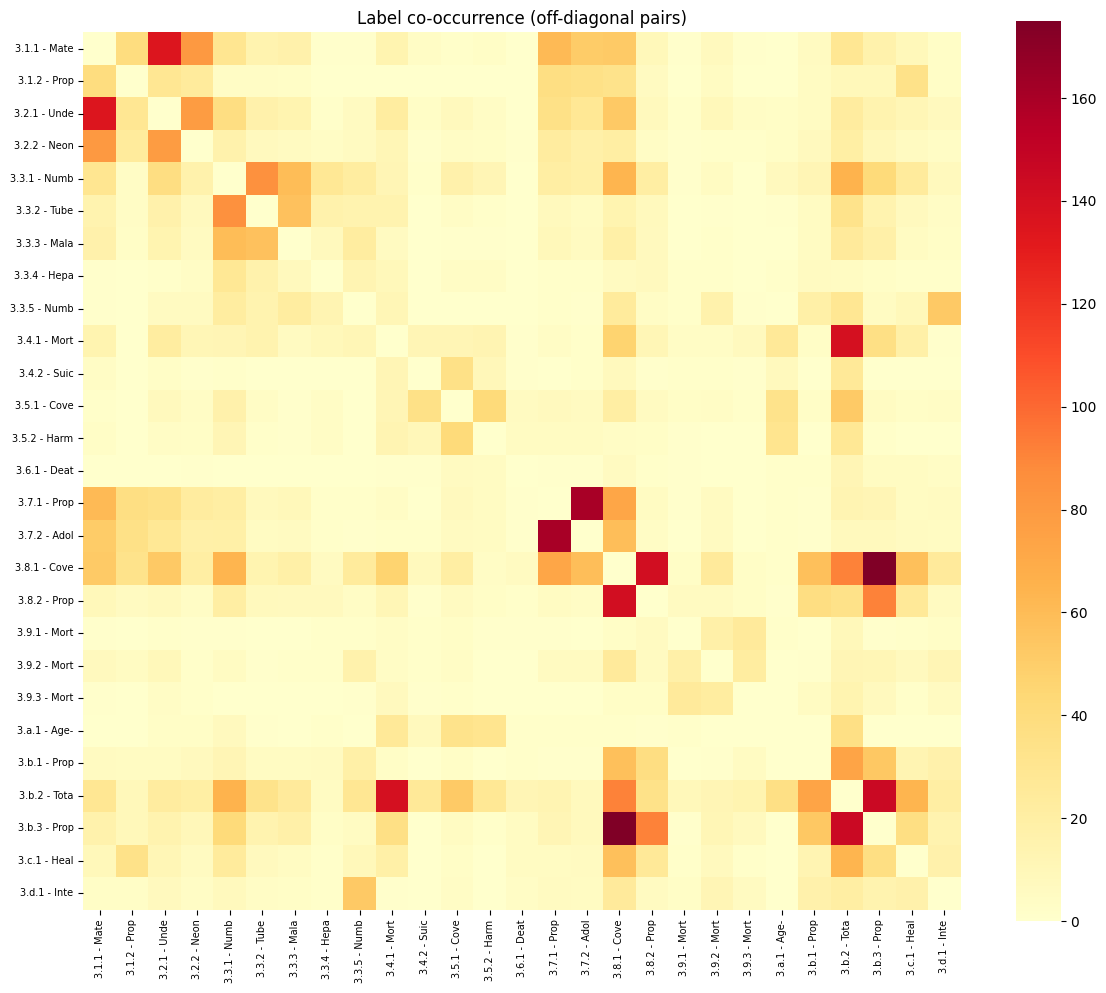

Top 10 co-occurring label pairs:


,label_a,label_b,co_count
256,3.8.1 - Coverage of essential health services ...,3.b.3 - Proportion of health facilities that h...,175
229,3.7.1 - Proportion of women of reproductive ag...,3.7.2 - Adolescent birth rate (aged 10_14 year...,160
291,3.b.2 - Total net official development assista...,3.b.3 - Proportion of health facilities that h...,145
249,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,141
179,3.4.1 - Mortality rate attributed to cardiovas...,3.b.2 - Total net official development assista...,140
1,3.1.1 - Maternal mortality ratio,3.2.1 - Under-5 mortality rate,135
255,3.8.1 - Coverage of essential health services ...,3.b.2 - Total net official development assista...,91
265,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,91
85,"3.3.1 - Number of new HIV infections per 1,000...","3.3.2 - Tuberculosis incidence per 100,000 pop...",85
2,3.1.1 - Maternal mortality ratio,3.2.2 - Neonatal mortality rate,80


In [6]:
# Label co-occurrence matrix (27 x 27)
cooccur = Y.T @ Y
np.fill_diagonal(cooccur, 0)

short_names = [n[:12] for n in label_names]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cooccur, xticklabels=short_names, yticklabels=short_names,
    cmap="YlOrRd", ax=ax, square=True,
)
ax.set_title("Label co-occurrence (off-diagonal pairs)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(label_names)):
    for j in range(i + 1, len(label_names)):
        if cooccur[i, j] > 0:
            pairs.append((label_names[i], label_names[j], int(cooccur[i, j])))
pairs_df = pd.DataFrame(pairs, columns=["label_a", "label_b", "co_count"]).sort_values("co_count", ascending=False)
print("Top 10 co-occurring label pairs:")
display(pairs_df.head(10))


In [ ]:
STOP_WORDS = set(nltk_stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def clean_html(text):
    """Remove HTML tags and normalize whitespace."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    return re.sub(r"\s+", " ", text).strip()


def preprocess_text(text, lowercase=False, remove_stopwords=False, lemmatize=False):
    """Full preprocessing pipeline with optional stages."""
    text = clean_html(text)
    if lowercase:
        text = text.lower()
    if remove_stopwords or lemmatize:
        tokens = text.split()
        if remove_stopwords:
            tokens = [t for t in tokens if t.lower() not in STOP_WORDS]
        if lemmatize:
            tokens = [LEMMATIZER.lemmatize(t.lower()) for t in tokens]
        text = " ".join(tokens)
    return text


PREP_VARIANTS = {
    "html_only": lambda t: preprocess_text(t),
    "lower": lambda t: preprocess_text(t, lowercase=True),
    "lower_nostop": lambda t: preprocess_text(t, lowercase=True, remove_stopwords=True),
    "lower_lemma": lambda t: preprocess_text(t, lowercase=True, remove_stopwords=True, lemmatize=True),
}

for name, fn in PREP_VARIANTS.items():
    col = f"prep_{name}"
    train_df[col] = train_df["Text"].apply(fn)
    test_df[col] = test_df["Text"].apply(fn)

train_df["clean_text"] = train_df["prep_html_only"]
test_df["clean_text"] = test_df["prep_html_only"]

print("Preprocessing preview (first train row):\n")
for name in PREP_VARIANTS:
    col = f"prep_{name}"
    print(f"{col} ({len(train_df.loc[0, col])} chars): {train_df.loc[0, col][:180]}...\n")

train_df["clean_len"] = train_df["clean_text"].str.len()
print(f"Avg length — raw: {train_df['text_len'].mean():.0f} | HTML cleaned: {train_df['clean_len'].mean():.0f}")
